# 🚀 Fase 3: Feature Engineering via Deep Learning Embeddings (PyTorch)
**LSTM Autoencoder para representação de Séries Temporais**

Nesta terceira e última fase do experimento, vamos utilizar Redes Neurais Profundas (Deep Learning) como *Extratoras de Features*. 
Em vez de depender da intuição humana (Lags/Médias) ou da extração massiva estatística (`tsfresh`), vamos treinar um **LSTM Autoencoder** para reconstruir as janelas de 7 dias das 5 variáveis do dataset Beijing PM2.5. O espaço latente (bottleneck) da rede será extraído e utilizado como Features de entrada para o nosso modelo campeão: o **Random Forest**.

Compararemos:
1. **Apenas Manual FE** (Baseline)
2. **Apenas DL Embeddings**
3. **Híbrido: Manual FE + DL Embeddings**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('dark_background')



## 1. Carregamento e Preparação do Dataset


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"
df_raw = pd.read_csv(url)

# Formatação
df_raw['date'] = pd.to_datetime(df_raw[['year', 'month', 'day', 'hour']])
cols_of_interest = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']
df_raw = df_raw[['date'] + cols_of_interest].copy()
df_raw['pm2.5'] = df_raw['pm2.5'].interpolate(method='linear')
df_raw = df_raw.dropna()

# Agregação Diária
df_daily = df_raw.set_index('date').resample('D').mean().reset_index()
print(f"Total de dias: {len(df_daily)}")

# Criação do Target (pm2.5 do dia seguinte)
df_daily['target'] = df_daily['pm2.5'].shift(-1)
df_daily = df_daily.dropna().reset_index(drop=True)



Total de dias: 1825


## 2. Baseline: Recriar a Feature Engineering Manual


In [3]:
# Vamos recriar as 31 features manuais rapidamente
df_manual = df_daily.copy()
lags = [1, 2, 3, 7]

for col in cols_of_interest:
    for lag in lags:
        df_manual[f'{col}_lag_{lag}'] = df_manual[col].shift(lag)
    df_manual[f'{col}_rolling_mean_7'] = df_manual[col].rolling(window=7).mean()

df_manual['month'] = df_manual['date'].dt.month
df_manual['day_of_week'] = df_manual['date'].dt.dayofweek
df_manual = df_manual.dropna().reset_index(drop=True)

# Vamos manter df_manual alinhado para o futuro
cols_to_drop = ['date', 'target'] + cols_of_interest
X_manual = df_manual.drop(columns=cols_to_drop)
y_manual = df_manual['target']



## 3. Preparando Tensores para o PyTorch (Sequências 3D)
O Autoencoder precisa de tensores no formato `(Num_Samples, Sequence_Length, Num_Features)`. Usaremos uma janela de 7 dias.


In [4]:
seq_length = 7
num_features = len(cols_of_interest)

# Redes neurais são muito sensíveis à escala dos dados
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_daily[cols_of_interest])

X_seq = []
for i in range(len(data_scaled) - seq_length):
    X_seq.append(data_scaled[i : i + seq_length])

X_seq = np.array(X_seq)
X_tensor = torch.tensor(X_seq, dtype=torch.float32)

print(f"Formato do Tensor de Entrada (Amostras, Timesteps, Variáveis): {X_tensor.shape}")

# Vamos alinhar o Manual FE com o X_seq. O X_seq[i] vai de i até i+6 (7 dias) para prever o target de i+6 (que é o i+7 real).
# O df_manual droppou Nans (temos lag 7 e rolling 7). Ou seja, o primeiro registro viável no df_manual corresponde ao 7º dia.
# O alinhamento dos arrays bate perfeitamente: len(X_seq) == len(df_manual) !
assert len(X_tensor) == len(df_manual)

dataset = TensorDataset(X_tensor, X_tensor) # Autoencoder: Entrada == Saída
loader = DataLoader(dataset, batch_size=32, shuffle=True)



Formato do Tensor de Entrada (Amostras, Timesteps, Variáveis): torch.Size([1817, 7, 5])


## 4. Arquitetura do LSTM Autoencoder e Treinamento
Comprimiremos 5 variáveis x 7 dias = 35 valores em um **espaço latente de 16 dimensões**.


Treinando LSTM Autoencoder no cuda...


Epoch 10/50, MSE Loss: 0.1700


Epoch 20/50, MSE Loss: 0.1151


Epoch 30/50, MSE Loss: 0.0905


Epoch 40/50, MSE Loss: 0.0880


Epoch 50/50, MSE Loss: 0.0727
Treinamento DL concluído em 6.79 segundos.


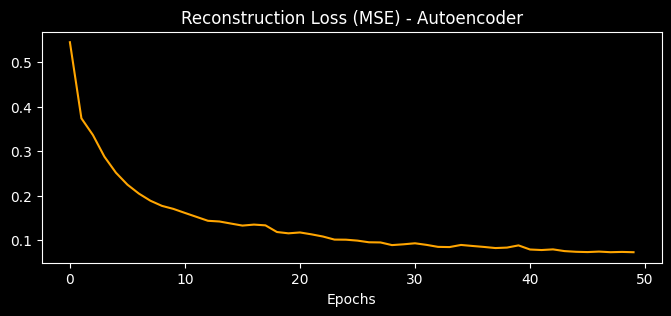

In [5]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=16):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.embedding_dim = embedding_dim
        
        # Encoder
        self.encoder_lstm = nn.LSTM(n_features, embedding_dim, batch_first=True)
        
        # Decoder
        self.decoder_lstm = nn.LSTM(embedding_dim, embedding_dim, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)
        
    def encode(self, x):
        # x shape: (batch, seq_len, n_features)
        out, (hidden, cell) = self.encoder_lstm(x)
        # pegamos o ultimo hidden state como o vetor de embedding representativo da serie
        # hidden shape: (1, batch, embedding_dim)
        embedding = hidden[-1, :, :]
        return embedding
    
    def decode(self, x):
        # x shape: (batch, embedding_dim)
        # Repetimos o vetor para a sequência inteira para o decoder
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.decoder_lstm(x)
        # out shape: (batch, seq_len, embedding_dim)
        reconstruction = self.output_layer(out)
        return reconstruction
        
    def forward(self, x):
        embedding = self.encode(x)
        reconstruction = self.decode(embedding)
        return reconstruction

# Configuração
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMAutoencoder(seq_length, num_features, embedding_dim=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(f"Treinando LSTM Autoencoder no {device}...")
epochs = 50
start_time = time.time()
losses = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, _ in loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        reconstruction = model(batch_x)
        loss = criterion(reconstruction, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, MSE Loss: {losses[-1]:.4f}")

dl_train_time = time.time() - start_time
print(f"Treinamento DL concluído em {dl_train_time:.2f} segundos.")

plt.figure(figsize=(8,3))
plt.plot(losses, color='orange')
plt.title('Reconstruction Loss (MSE) - Autoencoder')
plt.xlabel('Epochs')
plt.show()



## 5. Extração dos Embeddings
Agora que a rede aprendeu a comprimir a informação temporal, usaremos apenas a função `.encode()` para gerar as novas Features!


In [6]:
model.eval()
with torch.no_grad():
    X_tensor_device = X_tensor.to(device)
    embeddings = model.encode(X_tensor_device).cpu().numpy()

# Transformar num DataFrame
X_embeddings = pd.DataFrame(embeddings, columns=[f'embed_{i}' for i in range(16)])
print(f"Deep Learning Embeddings extraídos. Shape: {X_embeddings.shape}")



Deep Learning Embeddings extraídos. Shape: (1817, 16)


## 6. O Duelo Final (Random Forest)
Vamos testar o impacto desses embeddings injetando-os no Random Forest.


Treinando Florestas...


[1. Apenas Manual FE] MAE: 57.8834 | Tempo Treino: 0.78s


[2. Apenas DL Embeddings] MAE: 60.5868 | Tempo Treino: 0.50s


[3. Híbrido (Manual + Embeddings)] MAE: 57.2441 | Tempo Treino: 1.26s


,Cenário,N_Features,MAE,RMSE,Train_Time(s)
2,3. Híbrido (Manual + Embeddings),43,57.244112,78.068823,1.255478
0,1. Apenas Manual FE,27,57.883382,78.073064,0.777971
1,2. Apenas DL Embeddings,16,60.586756,82.107376,0.503539


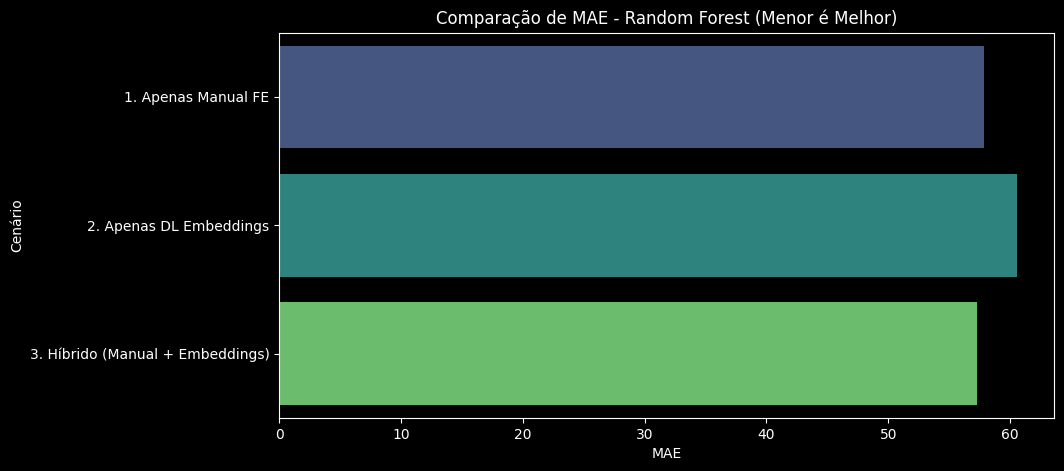

In [7]:
# 1. Dataset: Apenas Manual
X1 = X_manual

# 2. Dataset: Apenas Embeddings
X2 = X_embeddings

# 3. Dataset: Híbrido (Manual + Embeddings)
X3 = pd.concat([X_manual, X_embeddings], axis=1)

y = y_manual
test_size = 365

results = []

def evaluate_rf(X, name):
    X_train = X.iloc[:-test_size]
    y_train = y.iloc[:-test_size]
    X_test = X.iloc[-test_size:]
    y_test = y.iloc[-test_size:]
    
    rf = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
    
    start = time.time()
    rf.fit(X_train, y_train)
    t_time = time.time() - start
    
    preds = rf.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        'Cenário': name,
        'N_Features': X_train.shape[1],
        'MAE': mae,
        'RMSE': rmse,
        'Train_Time(s)': t_time
    })
    print(f"[{name}] MAE: {mae:.4f} | Tempo Treino: {t_time:.2f}s")

print("Treinando Florestas...")
evaluate_rf(X1, '1. Apenas Manual FE')
evaluate_rf(X2, '2. Apenas DL Embeddings')
evaluate_rf(X3, '3. Híbrido (Manual + Embeddings)')

res_df = pd.DataFrame(results)
display(res_df.sort_values('MAE'))

plt.figure(figsize=(10,5))
sns.barplot(data=res_df, x='MAE', y='Cenário', palette='viridis')
plt.title('Comparação de MAE - Random Forest (Menor é Melhor)')
plt.show()

